# 课程设计

学号：3250102780　姓名：李昊泽

使用 TorchVision 官方 ImageNet-1K 预训练特征，在课程 CIFAR-10 训练集上微调十分类模型。
以飞机 `0`、猫 `3`、青蛙 `6` 的平均准确率选择最佳模型，总体准确率作为平局判据。




## 1. 导入依赖
Kaggle 通常已安装以下依赖，无须升级 torch/torchvision。模型只依赖 TorchVision，不额外安装 timm。

In [1]:
import copy
import gc
import hashlib
import json
import math
import os
import pickle
import random
import time
from contextlib import nullcontext
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from IPython import get_ipython
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.models import ConvNeXt_Tiny_Weights, convnext_tiny
from tqdm.auto import tqdm

if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib', 'inline')

## 2. 运行模式与可修改参数
保留已取得较好成绩的 224 像素 ConvNeXt-Tiny 配置，实际最多训练 **2 轮分类头 + 10 轮全网络微调**。
本次运行设 **60 分钟预算**，通常预留最后 **5 分钟**用于完整验证、绘图和保存。
每轮开始前，根据已测得的同阶段耗时判断还能否完成下一轮；不会为凑满轮数一直运行。
计时从模型准备好以后开始，不包含预训练权重下载；在完整 epoch 边界停止，实际耗时仍会受 GPU 波动影响。

`MAX_FINETUNE_EPOCHS=10` 是实际轮数上限。下方配方中保留 `finetune_epochs=30`，
只为沿用原来的学习率曲线、增强调度和旧断点签名，**不代表仍要跑 30 轮**。
追加细调默认关闭。新实验使用独立的 `convnext_tiny_1h_v1` 输出目录，从 ImageNet 预训练权重开始重新微调。

`ACTION='train'` 训练/续训；`ACTION='evaluate'` 只加载最终权重评估。
首次运行启用 GPU 和 Internet；不能联网时填写官方 `PRETRAINED_PATH`。
`smoke` 只检查代码流程，默认不设时间限制。

In [4]:
SEED = 20260912
CLASS_NAMES = ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
TARGET_CLASSES = (0, 3, 6)
IS_KAGGLE = Path('/kaggle/working').is_dir()
RUN_MODE = os.getenv('CIFAR10_RUN_MODE', 'kaggle' if IS_KAGGLE else 'smoke').lower()
ACTION = os.getenv('CIFAR10_ACTION', 'train').lower()  # 'train' 或 'evaluate'
RUN_NAME = os.getenv('CIFAR10_RUN_NAME', 'convnext_tiny_1h_v1')
TIME_BUDGET_MINUTES = float(os.getenv('CIFAR10_TIME_BUDGET_MINUTES', '60' if RUN_MODE == 'kaggle' else '0'))
FINAL_RESERVE_MINUTES = 5.0
MAX_FINETUNE_EPOCHS = int(os.getenv('CIFAR10_MAX_FINETUNE_EPOCHS', '10'))
ENABLE_REFINEMENT = False  # 一小时方案不自动追加 10 轮
if TIME_BUDGET_MINUTES < 0 or MAX_FINETUNE_EPOCHS < 1:
    raise ValueError('时间预算不能为负，微调轮数上限必须大于 0。')
if 0 < TIME_BUDGET_MINUTES <= FINAL_RESERVE_MINUTES:
    raise ValueError('总预算须大于最终验证预留时间；设置为 0 表示不计时。')
DATA_PATH = os.getenv('CIFAR10_DATA_DIR', '')
PRETRAINED_PATH = os.getenv('CIFAR10_PRETRAINED_PATH', '')  # 官方 ImageNet 原始权重；留空自动下载
RESUME_PATH = os.getenv('CIFAR10_RESUME_PATH', '')  # 上次运行的迁移学习 last_checkpoint.pth
EVAL_WEIGHTS_PATH = os.getenv('CIFAR10_EVAL_WEIGHTS', '')  # ACTION='evaluate' 时可指定最终权重

PROFILES = {
    'smoke': dict(image_size=64, batch_size=2, accumulation=1, eval_batch_size=2,
                  head_epochs=1, finetune_epochs=1, refine_epochs=1, workers=0,
                  train_limit=20, valid_limit=20, pretrained=False),
    'local': dict(image_size=160, batch_size=4, accumulation=4, eval_batch_size=4,
                  head_epochs=1, finetune_epochs=3, refine_epochs=0, workers=0,
                  train_limit=1000, valid_limit=1000, pretrained=True),
    'kaggle': dict(image_size=224, batch_size=32, accumulation=2, eval_batch_size=32,
                   head_epochs=2, finetune_epochs=30, refine_epochs=10, workers=2,
                   train_limit=None, valid_limit=None, pretrained=True),
}
if RUN_MODE not in PROFILES or ACTION not in ('train', 'evaluate'):
    raise ValueError('RUN_MODE 仅支持 smoke/local/kaggle；ACTION 仅支持 train/evaluate。')
if not RUN_NAME or Path(RUN_NAME).name != RUN_NAME or RUN_NAME in ('.', '..'):
    raise ValueError('RUN_NAME 必须是单个目录名。')
CFG = PROFILES[RUN_MODE].copy()
CFG.update(head_lr=1e-3, backbone_lr=5e-5, finetune_head_lr=5e-4,
           weight_decay=0.05, smoothing=0.05, cutmix_probability=0.25,
           grad_clip=1.0, ema_decay=0.999, target_goal=0.95, use_tta=True)
assert CFG['batch_size'] > 0 and CFG['accumulation'] > 0

## 3. 设备、随机种子与输出目录
正式 Kaggle 模式要求 CUDA，防止未启用 GPU 就开始长训练。默认使用一张 GPU。
smoke、local、kaggle 使用不同目录，迁移学习也不会读取旧 WRN 检查点。

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if RUN_MODE == 'kaggle' and ACTION == 'train' and device.type != 'cuda':
    raise RuntimeError('请先在 Kaggle 打开 GPU Accelerator，再从头运行。')
USE_AMP = device.type == 'cuda'
torch.set_num_threads(min(4, os.cpu_count() or 1))
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
OUTPUT_ROOT = Path(os.getenv('CIFAR10_OUTPUT_DIR', '/kaggle/working' if IS_KAGGLE else str(Path.cwd())))
RUN_DIR = OUTPUT_ROOT / f'{RUN_NAME}_{RUN_MODE}'
RUN_DIR.mkdir(parents=True, exist_ok=True)
LAST_PATH = RUN_DIR / 'last_checkpoint.pth'
BEST_PATH = RUN_DIR / 'cifar10_convnext_tiny_best.pth'
FINAL_MODEL_PATH = RUN_DIR / 'cifar10_convnext_tiny.pth'
MODEL_CONFIG = dict(image_size=CFG['image_size'], use_tta=CFG['use_tta'])
print('PyTorch:', torch.__version__, '| TorchVision:', torchvision.__version__)
print('设备:', device, '| 模式:', RUN_MODE, '| 操作:', ACTION)
print('配置:', CFG)
print('输出目录:', RUN_DIR.resolve())
print('实际训练上限:', CFG['head_epochs'], '轮分类头 +', min(MAX_FINETUNE_EPOCHS, CFG['finetune_epochs']), '轮微调')
print('本次时间预算:', TIME_BUDGET_MINUTES or '不限制', '分钟；追加细调:', ENABLE_REFINEMENT)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
if RUN_MODE == 'smoke':
    print('SMOKE：随机初始化、小样本检查；本次准确率不代表迁移学习结果。')

PyTorch: 2.10.0+cu128 | TorchVision: 0.25.0+cu128
设备: cuda | 模式: kaggle | 操作: train
配置: {'image_size': 224, 'batch_size': 32, 'accumulation': 2, 'eval_batch_size': 32, 'head_epochs': 2, 'finetune_epochs': 30, 'refine_epochs': 10, 'workers': 2, 'train_limit': None, 'valid_limit': None, 'pretrained': True, 'head_lr': 0.001, 'backbone_lr': 5e-05, 'finetune_head_lr': 0.0005, 'weight_decay': 0.05, 'smoothing': 0.05, 'cutmix_probability': 0.25, 'grad_clip': 1.0, 'ema_decay': 0.999, 'target_goal': 0.95, 'use_tta': True}
输出目录: /kaggle/working/convnext_tiny_1h_v1_kaggle
实际训练上限: 2 轮分类头 + 10 轮微调
本次时间预算: 60.0 分钟；追加细调: False
GPU: Tesla T4


## 3.1 一小时预算如何生效
优先在完整 epoch 边界停止，断点中的模型、优化器和随机状态保持一致。
每次开新轮前，按近期同阶段最慢一轮耗时再留 15% 余量；剩余时间不足时直接进入最终验证和保存。
首次进入微调阶段尚无同阶段测速，会先运行一轮来获得耗时，因此这是约一小时的预算，不是硬性秒级中断。
预算与轮数上限不改变训练配方签名，可恢复已有 ConvNeXt 断点。重新 Run All 会重新计时；
如果断点已完成至少 10 轮微调，默认不再训练，直接保留历史最佳。

In [6]:
class RunBudget:
    def __init__(self, minutes, reserve_minutes=5.0):
        self.limit_seconds = minutes * 60 if minutes > 0 else float('inf')
        self.reserve_seconds = reserve_minutes * 60
        self.started_at = None

    def start(self):
        self.started_at = time.perf_counter()

    def elapsed(self):
        return 0.0 if self.started_at is None else time.perf_counter() - self.started_at

    def training_seconds_left(self):
        return max(0.0, self.limit_seconds - self.elapsed() - self.reserve_seconds)

    def can_start_epoch(self, estimated_seconds=0.0):
        # 估计值包括该轮训练、验证；另外加 15% 余量。
        return self.training_seconds_left() > estimated_seconds * 1.15

    def observe_validation(self, seconds):
        # GPU 较慢时，为最终全量验证和保存留出更多时间。
        self.reserve_seconds = max(self.reserve_seconds, seconds * 2 + 60)

budget = RunBudget(TIME_BUDGET_MINUTES, FINAL_RESERVE_MINUTES)
budget_stopped = False

## 4. 定位课程数据
路径优先使用 `DATA_PATH`，然后检查本地 `data` 和 Kaggle `/kaggle/input`。
如果附加了多个 CIFAR-10 数据目录，请显式指定路径。

In [7]:
REQUIRED_FILES = tuple(f'data_batch_{i}' for i in range(1, 6)) + ('test_batch',)

def is_cifar_dir(path):
    return path.is_dir() and all((path / name).is_file() for name in REQUIRED_FILES)

def discover_data_dir():
    if DATA_PATH:
        candidate = Path(DATA_PATH).expanduser()
        if not is_cifar_dir(candidate):
            raise FileNotFoundError(f'DATA_PATH 缺少课程数据文件：{candidate}')
        return candidate.resolve()
    cwd = Path.cwd()
    for candidate in (cwd / 'data', cwd / 'final/data', cwd.parent / 'final/data'):
        if is_cifar_dir(candidate):
            return candidate.resolve()
    root = Path('/kaggle/input')
    matches = sorted({p.parent for p in root.rglob('data_batch_1') if is_cifar_dir(p.parent)}) if root.exists() else []
    if len(matches) != 1:
        raise FileNotFoundError(f'找到 {len(matches)} 个课程数据目录，请设置 DATA_PATH：{matches}')
    return matches[0]

DATA_DIR = discover_data_dir()
print('数据目录:', DATA_DIR)

数据目录: /kaggle/input/competitions/2026zjutestfinal


## 5. 读取并校验数据
只把 `data_batch_1~5` 用于梯度训练，`test_batch` 用于课程规定的验证和模型选择。
pickle 仅加载课程提供的可信文件。验证集分数经过模型选择，不能当作独立隐藏测试成绩。

In [8]:
def read_course_pickle(path):
    with Path(path).open('rb') as stream:
        return pickle.load(stream, encoding='bytes')

def load_batches(names):
    xs, ys = [], []
    for name in names:
        batch = read_course_pickle(DATA_DIR / name)
        raw = np.asarray(batch[b'data'])
        labels = np.asarray(batch[b'labels'], dtype=np.int64)
        assert raw.shape == (10000, 3072) and raw.dtype == np.uint8, (name, raw.shape, raw.dtype)
        assert labels.shape == (10000,) and np.all((labels >= 0) & (labels < 10))
        xs.append(raw.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1))
        ys.append(labels)
    return np.concatenate(xs), np.concatenate(ys)

train_images, train_labels = load_batches([f'data_batch_{i}' for i in range(1, 6)])
valid_images, valid_labels = load_batches(['test_batch'])
assert train_images.shape == (50000, 32, 32, 3)
assert valid_images.shape == (10000, 32, 32, 3)
assert np.array_equal(np.bincount(train_labels, minlength=10), np.full(10, 5000))
assert np.array_equal(np.bincount(valid_labels, minlength=10), np.full(10, 1000))
if (DATA_DIR / 'batches.meta').is_file():
    names = read_course_pickle(DATA_DIR / 'batches.meta')[b'label_names']
    assert tuple(x.decode() if isinstance(x, bytes) else x for x in names) == CLASS_NAMES
print('训练/验证:', train_images.shape, valid_images.shape)
print('十类训练数量:', np.bincount(train_labels).tolist())
print('十类验证数量:', np.bincount(valid_labels).tolist())

训练/验证: (50000, 32, 32, 3) (10000, 32, 32, 3)
十类训练数量: [5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]
十类验证数量: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]


## 6. 数据集与增强
在原始 32×32 图片上随机裁剪、翻转和轻度 RandAugment；随后由模型统一放大到目标分辨率。
验证仅使用 `ToTensor()`。不要在外部重复做 Normalize，ImageNet 归一化已内置在 `net`。

In [10]:
class CIFAR10PickleDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images, self.labels, self.transform = images, labels, transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image = self.transform(Image.fromarray(self.images[index]))
        return image, int(self.labels[index])

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ToTensor(),
])
test_transform = transforms.ToTensor()

def select_subset(images, labels, transform, limit, seed):
    dataset = CIFAR10PickleDataset(images, labels, transform)
    if limit is None:
        return dataset
    rng = np.random.default_rng(seed)
    selected = np.concatenate([rng.permutation(np.flatnonzero(labels == cls))[:limit // 10] for cls in range(10)])
    return Subset(dataset, selected.tolist())

train_dataset = select_subset(train_images, train_labels, train_transform, CFG['train_limit'], SEED)
valid_dataset = select_subset(valid_images, valid_labels, test_transform, CFG['valid_limit'], SEED + 1)

## 7. DataLoader 与真实 batch 检查
每轮重建 worker 随机种子，支持 epoch 边界恢复。梯度累积用于降低显存占用。

In [11]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2 ** 32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)

loader_generator = torch.Generator().manual_seed(SEED)
loader_options = dict(num_workers=CFG['workers'], pin_memory=USE_AMP, worker_init_fn=seed_worker)
train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'], shuffle=True,
                          generator=loader_generator, **loader_options)
valid_loader = DataLoader(valid_dataset, batch_size=CFG['eval_batch_size'], shuffle=False, **loader_options)
sample_images, sample_labels = next(iter(valid_loader))
assert sample_images.ndim == 4 and sample_images.shape[1:] == (3, 32, 32)
assert sample_images.dtype == torch.float32 and 0 <= sample_images.min() <= sample_images.max() <= 1
print('使用的训练/验证样本:', len(train_dataset), len(valid_dataset))
print('真实输入:', tuple(sample_images.shape), '| 标签:', sample_labels.tolist())

使用的训练/验证样本: 50000 10000
真实输入: (32, 3, 32, 32) | 标签: [3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 4, 9, 5, 2, 4, 0, 9, 6, 6, 5]


## 8. 新旧 PyTorch 的 AMP 兼容
CUDA 使用新版 `torch.amp`；本地旧版缺少新 GradScaler 时回退。CPU 不开启混合精度。

In [13]:
def make_grad_scaler(enabled):
    amp_module = getattr(torch, 'amp', None)
    if amp_module is not None and hasattr(amp_module, 'GradScaler'):
        return amp_module.GradScaler('cuda', enabled=enabled)
    return torch.cuda.amp.GradScaler(enabled=enabled)

def amp_autocast(enabled=USE_AMP):
    if not enabled:
        return nullcontext()
    amp_module = getattr(torch, 'amp', None)
    if amp_module is not None and hasattr(amp_module, 'autocast'):
        return amp_module.autocast('cuda', dtype=torch.float16)
    return torch.cuda.amp.autocast(dtype=torch.float16)

## 9. 十分类迁移学习模型
ConvNeXt-Tiny 使用官方 `IMAGENET1K_V1` 权重，新分类头输出 10 类。
输入接口：RGB、NCHW、float `[0,1]` 或 uint8 `[0,255]`。`net` 内部进行双线性缩放与 ImageNet 归一化。
为保留 CIFAR-10 完整物体，采用整图缩放至 224，而不照搬 ImageNet 的中心裁剪。
推理时原图与水平翻转的 logits 取平均；训练时只前向一次。
最终重建时 `pretrained=False`，已训练的完整 state_dict 能离线恢复模型。

In [14]:
class CIFAR10TransferNet(nn.Module):
    def __init__(self, image_size=224, use_tta=True, pretrained=False, pretrained_path=''):
        super().__init__()
        weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained and not pretrained_path else None
        try:
            self.backbone = convnext_tiny(weights=weights, stochastic_depth_prob=0.1)
        except Exception as exc:
            if not pretrained:
                raise
            raise RuntimeError('预训练权重加载失败。打开 Internet，或把官方权重附加到 Kaggle 并填写 PRETRAINED_PATH。') from exc
        if pretrained and pretrained_path:
            path = Path(pretrained_path).expanduser()
            if not path.is_file():
                raise FileNotFoundError(path)
            self.backbone.load_state_dict(torch.load(path, map_location='cpu', weights_only=True), strict=True)
        in_features = self.backbone.classifier[2].in_features
        self.backbone.classifier[2] = nn.Linear(in_features, 10)
        nn.init.trunc_normal_(self.backbone.classifier[2].weight, std=0.02)
        nn.init.zeros_(self.backbone.classifier[2].bias)
        self.image_size, self.use_tta = image_size, use_tta
        self.register_buffer('input_mean', torch.tensor((0.485, 0.456, 0.406)).reshape(1, 3, 1, 1))
        self.register_buffer('input_std', torch.tensor((0.229, 0.224, 0.225)).reshape(1, 3, 1, 1))

    def forward(self, images):
        if images.ndim != 4 or images.shape[1] != 3:
            raise ValueError('net 需要 NCHW 格式的三通道 RGB 图片。')
        x = images.float().div(255) if images.dtype == torch.uint8 else images.float()
        x = F.interpolate(x, size=(self.image_size, self.image_size), mode='bilinear', align_corners=False)
        x = ((x - self.input_mean) / self.input_std).contiguous(memory_format=torch.channels_last)
        logits = self.backbone(x)
        if not self.training and self.use_tta:
            logits = (logits + self.backbone(x.flip(-1))) * 0.5
        return logits

def build_model(pretrained=False):
    return CIFAR10TransferNet(**MODEL_CONFIG, pretrained=pretrained, pretrained_path=PRETRAINED_PATH)

## 10. 微调阶段和参数组
第一阶段冻结特征提取器，训练新分类头；第二阶段解冻全部参数，预训练层的学习率比分类头低 10 倍。
AdamW 对归一化参数和 bias 不施加 weight decay；每个阶段使用 warmup 和余弦学习率。

In [15]:
STAGES = [
    dict(name='head', epochs=CFG['head_epochs'], backbone_lr=0.0, head_lr=CFG['head_lr'], warmup=1),
    dict(name='finetune', epochs=CFG['finetune_epochs'], backbone_lr=CFG['backbone_lr'],
         head_lr=CFG['finetune_head_lr'], warmup=3),
    dict(name='refine', epochs=CFG['refine_epochs'], backbone_lr=1e-5, head_lr=1e-4, warmup=0),
]
RECIPE = dict(version='convnext-transfer-v1', mode=RUN_MODE, model=MODEL_CONFIG, stages=STAGES,
              seed=SEED, effective_batch=CFG['batch_size'] * CFG['accumulation'],
              weight_decay=CFG['weight_decay'], smoothing=CFG['smoothing'],
              cutmix=CFG['cutmix_probability'], ema_decay=CFG['ema_decay'],
              train_limit=CFG['train_limit'], valid_limit=CFG['valid_limit'],
              pretrained=CFG['pretrained'], target_goal=CFG['target_goal'])
SIGNATURE = hashlib.sha256(json.dumps(RECIPE, sort_keys=True).encode()).hexdigest()

def configure_optimizer(model, stage):
    buckets = {}
    for name, parameter in model.named_parameters():
        is_head = name.startswith('backbone.classifier.')
        parameter.requires_grad_(is_head or stage['name'] != 'head')
        if parameter.requires_grad:
            lr = stage['head_lr'] if is_head else stage['backbone_lr']
            decay = CFG['weight_decay'] if parameter.ndim > 1 and not name.endswith('.bias') else 0.0
            buckets.setdefault((lr, decay), []).append(parameter)
    groups = [dict(params=params, lr=lr, base_lr=lr, weight_decay=decay) for (lr, decay), params in buckets.items()]
    return torch.optim.AdamW(groups)

def set_stage_lr(optimizer, stage, epoch):
    warmup = min(stage['warmup'], max(0, stage['epochs'] - 1))
    if epoch < warmup:
        factor = (epoch + 1) / warmup
    else:
        progress = (epoch - warmup) / max(1, stage['epochs'] - warmup - 1)
        factor = 0.02 + 0.98 * 0.5 * (1 + math.cos(math.pi * min(progress, 1)))
    for group in optimizer.param_groups:
        group['lr'] = group['base_lr'] * factor

## 11. 轻度标签平滑与 CutMix
分类头热身和最后细调不用 CutMix；全网络阶段前期以 25% 概率使用，最后 5 轮关闭。

In [16]:
def cutmix_batch(images, targets, probability):
    soft = F.one_hot(targets, 10).float() * (1 - CFG['smoothing']) + CFG['smoothing'] / 10
    if images.size(0) < 2 or random.random() >= probability:
        return images, soft
    lam = float(np.random.beta(1.0, 1.0))
    height, width = images.shape[-2:]
    cut_h, cut_w = int(height * math.sqrt(1 - lam)), int(width * math.sqrt(1 - lam))
    cy, cx = random.randrange(height), random.randrange(width)
    y1, y2 = max(0, cy - cut_h // 2), min(height, cy + cut_h // 2)
    x1, x2 = max(0, cx - cut_w // 2), min(width, cx + cut_w // 2)
    order = torch.randperm(images.size(0), device=images.device)
    mixed = images.clone()
    mixed[:, :, y1:y2, x1:x2] = images[order, :, y1:y2, x1:x2]
    lam = 1 - (y2 - y1) * (x2 - x1) / (height * width)
    return mixed, soft * lam + soft[order] * (1 - lam)

## 12. EMA 权重
EMA 平滑训练权重，前期采用渐增衰减以避免新分类头适应过慢。最终只保留一个模型，不做多模型集成。

In [17]:
class ModelEMA:
    def __init__(self, model):
        self.module = copy.deepcopy(model).eval().requires_grad_(False)
        self.updates = 0

    @torch.no_grad()
    def update(self, model):
        self.updates += 1
        decay = min(CFG['ema_decay'], (1 + self.updates) / (10 + self.updates))
        source = model.state_dict()
        for key, value in self.module.state_dict().items():
            incoming = source[key].detach()
            if value.is_floating_point():
                value.lerp_(incoming, 1 - decay)
            else:
                value.copy_(incoming)

## 13. 验证指标
混淆矩阵行为真实类别、列为预测类别。每一类必须有验证样本；全程检查 logits 与 loss 是否有限。

In [18]:
@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    confusion = torch.zeros(10, 10, dtype=torch.long)
    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        with amp_autocast():
            logits = model(images)
        if not torch.isfinite(logits).all():
            raise FloatingPointError('验证输出出现 NaN/Inf。')
        predictions = logits.argmax(1).cpu()
        confusion += torch.bincount(targets.long() * 10 + predictions, minlength=100).reshape(10, 10)
    counts = confusion.sum(1)
    if (counts == 0).any():
        raise ValueError('验证集必须覆盖全部十类。')
    accuracy = confusion.diag().double() / counts
    return dict(overall=(confusion.diag().sum() / confusion.sum()).item(),
                target_macro=accuracy[list(TARGET_CLASSES)].mean().item(),
                class_accuracy=accuracy.tolist(), confusion=confusion.tolist())

def metric_is_better(metrics, best):
    return best is None or (metrics['target_macro'], metrics['overall']) > (best['target_macro'], best['overall'])

def print_metrics(metrics):
    print(f"总体 {metrics['overall']:.2%} | 飞机/猫/青蛙均值 {metrics['target_macro']:.2%}")
    print(' | '.join(f'{name}: {value:.2%}' for name, value in zip(CLASS_NAMES, metrics['class_accuracy'])))

## 14. 保存和恢复工具
`last_checkpoint.pth` 保存当前模型、EMA、优化器、scaler、阶段、随机状态、历史和最佳权重。
最佳权重嵌入同一个断点文件，避免 Kaggle 重启后只找到 last 却丢失 best。
纯模型文件均可用 `weights_only=True` 加载；训练断点也仅保存 Tensor 和基本 Python 类型。

In [19]:
def atomic_torch_save(payload, path):
    temporary = path.with_suffix(path.suffix + '.tmp')
    torch.save(payload, temporary)
    temporary.replace(path)

def cpu_state(model):
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

def capture_rng():
    np_state = np.random.get_state()
    return dict(python=random.getstate(), numpy=(np_state[0], np_state[1].tolist(), *np_state[2:]),
                torch=torch.get_rng_state(), cuda=torch.cuda.get_rng_state_all() if USE_AMP else [])

def restore_rng(state):
    random.setstate(state['python'])
    np_state = state['numpy']
    np.random.set_state((np_state[0], np.asarray(np_state[1], dtype=np.uint32), *np_state[2:]))
    torch.set_rng_state(state['torch'])
    if USE_AMP and len(state['cuda']) == torch.cuda.device_count():
        torch.cuda.set_rng_state_all(state['cuda'])

def save_checkpoint(stage_index, next_epoch, optimizer, scaler):
    payload = dict(signature=SIGNATURE, recipe=RECIPE, model_config=MODEL_CONFIG,
                   stage_index=stage_index, next_epoch=next_epoch, model=cpu_state(net),
                   ema=cpu_state(ema.module), ema_updates=ema.updates,
                   optimizer=optimizer.state_dict(), scaler=scaler.state_dict(),
                   history=history, best_metrics=best_metrics, best_info=best_info,
                   best_state=best_state, rng=capture_rng(),
                   run_budget=dict(minutes=TIME_BUDGET_MINUTES, elapsed_seconds=budget.elapsed(),
                                   max_finetune_epochs=MAX_FINETUNE_EPOCHS))
    atomic_torch_save(payload, LAST_PATH)

## 15. 单轮训练
使用梯度累积、AMP、梯度裁剪；最后不足一组的 batch 按实际样本数加权。
进度条显示当前阶段；首轮完成后输出本阶段剩余时间估计，时间以实际 GPU 为准。

In [20]:
def train_one_epoch(model, ema, optimizer, scaler, stage, epoch, global_epoch):
    seed_everything(SEED + global_epoch)
    loader_generator.manual_seed(SEED + global_epoch)
    model.train()
    if stage['name'] == 'head':
        model.backbone.features.eval()  # 冻结特征时也关闭 stochastic depth
    probability = CFG['cutmix_probability'] if stage['name'] == 'finetune' and epoch < stage['epochs'] - 5 else 0.0
    optimizer.zero_grad(set_to_none=True)
    loss_sum, count = 0.0, 0
    steps, accumulation = len(train_loader), CFG['accumulation']
    display_epochs = min(stage['epochs'], MAX_FINETUNE_EPOCHS) if stage['name'] == 'finetune' else stage['epochs']
    progress = tqdm(train_loader, desc=f"{stage['name']} {epoch + 1}/{display_epochs}", leave=False)
    for step, (images, targets) in enumerate(progress):
        images, targets = images.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        images, soft_targets = cutmix_batch(images, targets, probability)
        window_start = (step // accumulation) * accumulation
        window_samples = min(accumulation * CFG['batch_size'], len(train_dataset) - window_start * CFG['batch_size'])
        with amp_autocast():
            logits = model(images)
            loss = -(soft_targets * F.log_softmax(logits.float(), dim=1)).sum(1).mean()
        if not torch.isfinite(loss):
            raise FloatingPointError(f'训练损失异常：{loss.item()}')
        scaler.scale(loss * images.size(0) / window_samples).backward()
        if (step + 1) % accumulation == 0 or step + 1 == steps:
            scaler.unscale_(optimizer)
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            if not USE_AMP and not torch.isfinite(grad_norm):
                raise FloatingPointError('梯度出现 NaN/Inf。')
            old_scale = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            if scaler.get_scale() >= old_scale:
                ema.update(model)  # AMP 跳过优化器更新时不更新 EMA
            optimizer.zero_grad(set_to_none=True)
        loss_sum += loss.detach().item() * images.size(0)
        count += images.size(0)
        progress.set_postfix(loss=f'{loss_sum / count:.4f}')
    return loss_sum / count

## 16. 初始化模型或恢复训练
首次完整训练必须成功加载预训练权重；加载失败会停止，不会偷偷退回随机训练。
同一 session 自动读取当前目录断点。跨 session：把上次输出作为输入附加，设置 `RESUME_PATH` 为其中的迁移学习断点。
一小时的运行预算和 `MAX_FINETUNE_EPOCHS` 不改变训练配方，可直接读取原 ConvNeXt 断点。
例如原训练已到微调第 15 轮、上限设 10 时，会直接跳过训练并加载断点中历史最佳权重。
修改模型或学习率等配方仍会拒绝旧断点；`RESUME_PATH` 不应指向旧 WRN 文件。

In [21]:
resume_state = None
history, best_metrics, best_state, best_info = [], None, None, None
resume_stage, resume_epoch = 0, 0
if ACTION == 'train':
    resume_file = Path(RESUME_PATH).expanduser() if RESUME_PATH else LAST_PATH
    if RESUME_PATH and not resume_file.is_file():
        raise FileNotFoundError(f'RESUME_PATH 不存在：{resume_file}')
    if resume_file.is_file():
        resume_state = torch.load(resume_file, map_location='cpu', weights_only=True)
        if resume_state.get('signature') != SIGNATURE:
            raise ValueError('断点模型/配方与当前配置不同；请检查 RUN_MODE、轮数、有效 batch，或改 RUN_NAME 开始新实验。')
        resume_stage, resume_epoch = resume_state['stage_index'], resume_state['next_epoch']
        history, best_metrics = resume_state['history'], resume_state['best_metrics']
        best_state, best_info = resume_state['best_state'], resume_state['best_info']
    elif BEST_PATH.exists() or FINAL_MODEL_PATH.exists():
        raise FileExistsError('目录已有训练权重但缺少 last；请设置 RESUME_PATH，或用 ACTION=evaluate，或改 RUN_NAME。')
    net = build_model(pretrained=CFG['pretrained'] and resume_state is None).to(device, memory_format=torch.channels_last)
    if resume_state is not None:
        net.load_state_dict(resume_state['model'])
    ema = ModelEMA(net)
    if resume_state is not None:
        ema.module.load_state_dict(resume_state['ema'])
        ema.updates = resume_state['ema_updates']
        atomic_torch_save(best_state, BEST_PATH)
        print(f'恢复阶段 {STAGES[resume_stage]["name"]}，已完成 {resume_epoch} 轮；累计 {len(history)} 轮。')
    print('参数量:', f'{sum(p.numel() for p in net.parameters()):,}')
    print('初始化来源:', '训练断点' if resume_state else ('ImageNet-1K 官方预训练权重' if CFG['pretrained'] else 'SMOKE 随机初始化'))
    budget.start()  # 预训练权重下载完成后开始计时
else:
    print('只评估：跳过预训练权重下载和所有训练阶段。')

参数量: 27,827,818
初始化来源: ImageNet-1K 官方预训练权重


## 17. 执行一个训练阶段
逐轮验证 EMA，并按飞机、猫、青蛙平均准确率选择最佳模型；保持原图加翻转的 TTA 验证。
一小时方案省去阶段末额外的原始权重评估。达到轮数上限或预算不足时，继续运行后续评估和保存单元格。

In [23]:
def run_stage(stage_index):
    global net, ema, history, best_metrics, best_state, best_info, resume_state, budget_stopped
    if ACTION != 'train' or budget_stopped:
        return
    stage = STAGES[stage_index]
    if stage['name'] == 'refine' and not ENABLE_REFINEMENT:
        print('一小时方案：追加细调已关闭。')
        return
    epoch_limit = min(stage['epochs'], MAX_FINETUNE_EPOCHS) if stage['name'] == 'finetune' else stage['epochs']
    if stage_index < resume_stage or stage['epochs'] == 0:
        print('跳过已完成或未启用阶段:', stage['name'])
        return
    continuing = resume_state is not None and stage_index == resume_stage
    start_epoch = resume_epoch if continuing else 0
    if start_epoch >= epoch_limit:
        print('此阶段已完成:', stage['name'])
        resume_state = None
        return
    if stage['name'] == 'refine' and not continuing:
        if best_metrics is not None and best_metrics['target_macro'] >= CFG['target_goal']:
            print('目标三类平均已达到目标，跳过追加细调。')
            return
        net.load_state_dict(best_state)
        ema = ModelEMA(net)
    optimizer = configure_optimizer(net, stage)
    scaler = make_grad_scaler(USE_AMP)
    if continuing:
        optimizer.load_state_dict(resume_state['optimizer'])
        scaler.load_state_dict(resume_state['scaler'])
        restore_rng(resume_state['rng'])
        resume_state = None
    for epoch in range(start_epoch, epoch_limit):
        recent = [record['seconds'] for record in history if record['stage'] == stage['name']][-3:]
        estimate = max(recent, default=0.0)
        if not budget.can_start_epoch(estimate):
            print(f'预算不足以安全完成下一轮，保留最佳权重；本次已用 {budget.elapsed() / 60:.1f} 分钟。')
            budget_stopped = True
            break
        started = time.perf_counter()
        set_stage_lr(optimizer, stage, epoch)
        loss = train_one_epoch(net, ema, optimizer, scaler, stage, epoch, len(history))
        validation_started = time.perf_counter()
        metrics = evaluate(ema.module, valid_loader)
        budget.observe_validation(time.perf_counter() - validation_started)
        candidates = [('ema', ema.module, metrics)]
        for source, model, candidate in candidates:
            if metric_is_better(candidate, best_metrics):
                best_metrics, best_state = candidate, cpu_state(model)
                best_info = dict(stage=stage['name'], epoch=epoch + 1, global_epoch=len(history) + 1, source=source)
                atomic_torch_save(best_state, BEST_PATH)
        elapsed = time.perf_counter() - started
        history.append(dict(stage=stage['name'], epoch=epoch + 1, train_loss=loss,
                            overall=metrics['overall'], target_macro=metrics['target_macro'],
                            class_accuracy=metrics['class_accuracy'], seconds=elapsed,
                            lrs=[group['lr'] for group in optimizer.param_groups]))
        save_checkpoint(stage_index, epoch + 1, optimizer, scaler)
        print(f"\n{stage['name']} {epoch + 1}/{epoch_limit} | loss {loss:.4f} | {elapsed / 60:.1f} min")
        print_metrics(metrics)
        print(f"历史最佳三类平均 {best_metrics['target_macro']:.2%}，来源 {best_info}")
        if epoch == start_epoch:
            print(f"按本轮估计本阶段剩余约 {elapsed * (epoch_limit - epoch - 1) / 60:.1f} 分钟。")
        if math.isfinite(budget.limit_seconds):
            print(f'训练预算剩余 {budget.training_seconds_left() / 60:.1f} 分钟，另留 {budget.reserve_seconds / 60:.1f} 分钟用于收尾。')
    del optimizer, scaler
    gc.collect()
    if USE_AMP:
        torch.cuda.empty_cache()

## 18. 阶段一：训练分类头
冻结 ImageNet 特征，先让随机初始化的十分类头适应课程数据。

In [24]:
run_stage(0)

head 1/2:   0%|          | 0/1563 [00:00<?, ?it/s]


head 1/2 | loss 0.6830 | 2.3 min
总体 93.66% | 飞机/猫/青蛙均值 92.73%
airplane: 93.90% | automobile: 97.10% | bird: 90.70% | cat: 87.00% | deer: 92.40% | dog: 92.30% | frog: 97.30% | horse: 93.50% | ship: 96.40% | truck: 96.00%
历史最佳三类平均 92.73%，来源 {'stage': 'head', 'epoch': 1, 'global_epoch': 1, 'source': 'ema'}
按本轮估计本阶段剩余约 2.3 分钟。
训练预算剩余 52.4 分钟，另留 5.0 分钟用于收尾。


head 2/2:   0%|          | 0/1563 [00:00<?, ?it/s]


head 2/2 | loss 0.5922 | 2.1 min
总体 93.95% | 飞机/猫/青蛙均值 92.97%
airplane: 93.70% | automobile: 97.20% | bird: 91.20% | cat: 87.90% | deer: 92.50% | dog: 92.10% | frog: 97.30% | horse: 94.70% | ship: 96.70% | truck: 96.20%
历史最佳三类平均 92.97%，来源 {'stage': 'head', 'epoch': 2, 'global_epoch': 2, 'source': 'ema'}
训练预算剩余 50.4 分钟，另留 5.0 分钟用于收尾。


## 19. 阶段二：全网络微调
解冻全部层，使用较低 backbone 学习率保留预训练特征，同时适应 CIFAR-10。
实际最多执行 `MAX_FINETUNE_EPOCHS` 轮，默认 10；剩余时间不足时提前结束。学习率仍沿用原配方的前段。

In [25]:
run_stage(1)

finetune 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]


finetune 1/10 | loss 0.6793 | 5.4 min
总体 96.93% | 飞机/猫/青蛙均值 95.87%
airplane: 97.30% | automobile: 98.70% | bird: 96.80% | cat: 91.20% | deer: 96.80% | dog: 95.60% | frog: 99.10% | horse: 97.60% | ship: 98.80% | truck: 97.40%
历史最佳三类平均 95.87%，来源 {'stage': 'finetune', 'epoch': 1, 'global_epoch': 3, 'source': 'ema'}
按本轮估计本阶段剩余约 48.3 分钟。
训练预算剩余 44.4 分钟，另留 5.0 分钟用于收尾。


finetune 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]


finetune 2/10 | loss 0.5942 | 4.8 min
总体 97.72% | 飞机/猫/青蛙均值 97.37%
airplane: 98.60% | automobile: 98.60% | bird: 97.80% | cat: 94.10% | deer: 97.60% | dog: 96.20% | frog: 99.40% | horse: 98.20% | ship: 98.90% | truck: 97.80%
历史最佳三类平均 97.37%，来源 {'stage': 'finetune', 'epoch': 2, 'global_epoch': 4, 'source': 'ema'}
训练预算剩余 39.6 分钟，另留 5.0 分钟用于收尾。


finetune 3/10:   0%|          | 0/1563 [00:00<?, ?it/s]

...


finetune 7/10 | loss 0.5013 | 4.8 min
总体 98.55% | 飞机/猫/青蛙均值 98.20%
airplane: 99.30% | automobile: 99.10% | bird: 98.30% | cat: 95.70% | deer: 98.80% | dog: 97.50% | frog: 99.60% | horse: 99.30% | ship: 99.50% | truck: 98.40%
历史最佳三类平均 98.20%，来源 {'stage': 'finetune', 'epoch': 7, 'global_epoch': 9, 'source': 'ema'}
训练预算剩余 14.7 分钟，另留 5.0 分钟用于收尾。


finetune 8/10:   0%|          | 0/1563 [00:00<?, ?it/s]


finetune 8/10 | loss 0.4921 | 5.3 min
总体 98.50% | 飞机/猫/青蛙均值 98.30%
airplane: 99.30% | automobile: 98.90% | bird: 98.40% | cat: 96.00% | deer: 98.30% | dog: 97.30% | frog: 99.60% | horse: 99.20% | ship: 99.60% | truck: 98.40%
历史最佳三类平均 98.30%，来源 {'stage': 'finetune', 'epoch': 8, 'global_epoch': 10, 'source': 'ema'}
训练预算剩余 9.4 分钟，另留 5.0 分钟用于收尾。


finetune 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]


finetune 9/10 | loss 0.4726 | 4.8 min
总体 98.67% | 飞机/猫/青蛙均值 98.63%
airplane: 99.60% | automobile: 99.00% | bird: 98.90% | cat: 96.70% | deer: 98.50% | dog: 97.10% | frog: 99.60% | horse: 99.40% | ship: 99.40% | truck: 98.50%
历史最佳三类平均 98.63%，来源 {'stage': 'finetune', 'epoch': 9, 'global_epoch': 11, 'source': 'ema'}
训练预算剩余 4.6 分钟，另留 5.0 分钟用于收尾。
预算不足以安全完成下一轮，保留最佳权重；本次已用 50.4 分钟。


## 20. 追加细调（默认关闭）
一小时方案不会为达到目标继续追加轮数，直接使用预算内取得的最佳模型。
只有明确把 `ENABLE_REFINEMENT` 改成 `True` 且时间足够时才会运行这一阶段。

In [ ]:
run_stage(2)

## 21. 恢复最佳模型并输出十类指标
`ACTION='evaluate'` 从最终 `.pth` 读取，并从相邻 `model_config.json` 恢复训练分辨率。
最终文件和配置请一起保存；定义类以后加载完整 state_dict 不依赖 Internet。

In [26]:
if ACTION == 'evaluate':
    selected_path = Path(EVAL_WEIGHTS_PATH).expanduser() if EVAL_WEIGHTS_PATH else FINAL_MODEL_PATH
    config_path = selected_path.parent / 'model_config.json'
    if not config_path.is_file():
        raise FileNotFoundError(f'评估需要训练时的 model_config.json：{config_path}')
    with config_path.open(encoding='utf-8') as stream:
        saved_config = json.load(stream)
    MODEL_CONFIG = saved_config['model_config']
    best_info = saved_config['best_info']
    history_path = selected_path.parent / 'training_history.json'
    if history_path.is_file():
        with history_path.open(encoding='utf-8') as stream:
            history = json.load(stream)
else:
    selected_path = BEST_PATH
if not selected_path.is_file():
    raise FileNotFoundError(f'还没有可评估的模型：{selected_path}')
if 'ema' in globals():
    del ema
if 'net' in globals():
    del net
best_state = None
gc.collect()
if USE_AMP:
    torch.cuda.empty_cache()
net = build_model(pretrained=False).to(device, memory_format=torch.channels_last)
net.load_state_dict(torch.load(selected_path, map_location='cpu', weights_only=True))
net.eval()
final_metrics = evaluate(net, valid_loader)
print('最佳轮次:', best_info)
print('验证样本数:', len(valid_dataset))
print_metrics(final_metrics)
if len(valid_dataset) < 10000:
    print('本次仅验证子集，不是完整 10,000 张验证成绩。')

最佳轮次: {'stage': 'finetune', 'epoch': 9, 'global_epoch': 11, 'source': 'ema'}
验证样本数: 10000
总体 98.67% | 飞机/猫/青蛙均值 98.63%
airplane: 99.60% | automobile: 99.00% | bird: 98.90% | cat: 96.70% | deer: 98.50% | dog: 97.10% | frog: 99.60% | horse: 99.40% | ship: 99.40% | truck: 98.50%


## 22. 学习曲线与混淆矩阵
曲线记录各轮 EMA 的验证分数；如果最终选中原始权重，最终指标以第 21 节输出为准。

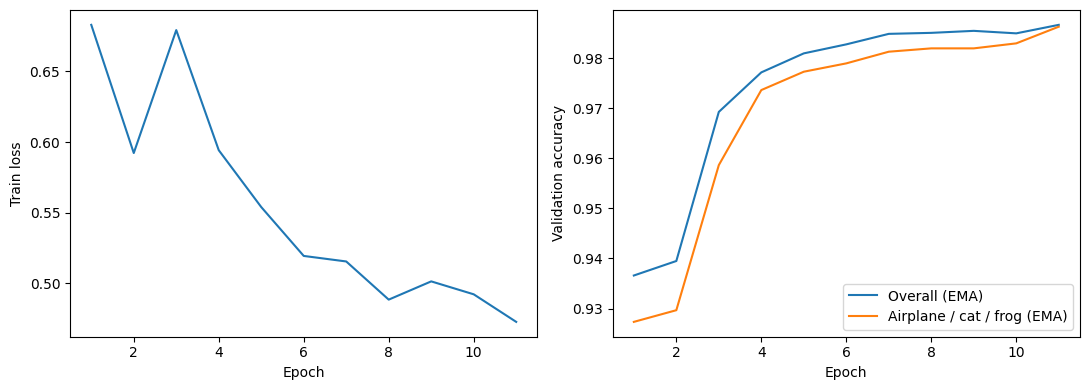

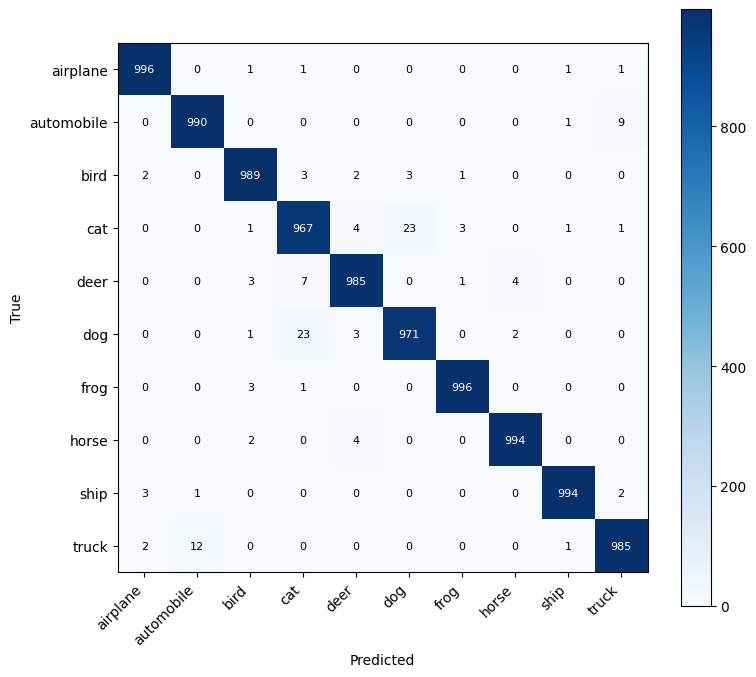

In [27]:
if history:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    epochs = np.arange(1, len(history) + 1)
    axes[0].plot(epochs, [r['train_loss'] for r in history])
    axes[0].set(xlabel='Epoch', ylabel='Train loss')
    axes[1].plot(epochs, [r['overall'] for r in history], label='Overall (EMA)')
    axes[1].plot(epochs, [r['target_macro'] for r in history], label='Airplane / cat / frog (EMA)')
    axes[1].set(xlabel='Epoch', ylabel='Validation accuracy')
    axes[1].legend()
    fig.tight_layout()
    plt.show()
matrix = np.asarray(final_metrics['confusion'])
fig, ax = plt.subplots(figsize=(8, 7))
plot = ax.imshow(matrix, cmap='Blues')
fig.colorbar(plot, ax=ax)
ax.set(xticks=range(10), yticks=range(10), xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
       xlabel='Predicted', ylabel='True')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
for row in range(10):
    for col in range(10):
        ax.text(col, row, str(matrix[row, col]), ha='center', va='center',
                color='white' if matrix[row, col] > matrix.max() / 2 else 'black', fontsize=8)
fig.tight_layout()
plt.show()

## 23. 保存 net 的权重
`net` 已装入最佳十分类权重。以下显式使用 `torch.save(net.state_dict(), ...)` 保存纯 state_dict。
JSON 文件只记录模型配置和真实指标，方便跨 session 恢复；不额外生成实验报告。

In [28]:
torch.save(net.state_dict(), FINAL_MODEL_PATH)
def write_json(payload, path):
    with path.open('w', encoding='utf-8') as stream:
        json.dump(payload, stream, ensure_ascii=False, indent=2, allow_nan=False)

provenance = saved_config if ACTION == 'evaluate' else dict(
    recipe=RECIPE, pretrained_source=ConvNeXt_Tiny_Weights.IMAGENET1K_V1.url if CFG['pretrained'] else 'smoke: random',
    torch_version=str(torch.__version__), torchvision_version=str(torchvision.__version__))
model_record = dict(provenance, model_config=MODEL_CONFIG, best_info=best_info,
                    input_contract='RGB NCHW float [0,1] or uint8 [0,255]; do not Normalize outside net')
write_json(model_record, RUN_DIR / 'model_config.json')
write_json(history, RUN_DIR / 'training_history.json')
write_json(dict(final_metrics, best_info=best_info, evaluated_samples=len(valid_dataset),
                evaluation_mode=RUN_MODE,
                elapsed_run_seconds=budget.elapsed() if ACTION == 'train' else None,
                budget_stopped=budget_stopped), RUN_DIR / 'validation_metrics.json')
print('已保存纯 state_dict:', FINAL_MODEL_PATH)

已保存纯 state_dict: /kaggle/working/convnext_tiny_1h_v1_kaggle/cifar10_convnext_tiny.pth


## 24. 重新创建 net、加载权重并 net.eval()
重建不下载任何预训练权重。用真实 batch 比较保存前后的输出，并检查最终变量 `net` 的评估状态。
GPU 允许极小浮点误差，但预测类别必须完全一致。助教可直接调用 `net(images)`。

In [29]:
verification_images = next(iter(valid_loader))[0][:2].to(device)
with torch.inference_mode(), amp_autocast():
    expected_logits = net(verification_images).float().cpu()
del net
gc.collect()
if USE_AMP:
    torch.cuda.empty_cache()
net = CIFAR10TransferNet(**MODEL_CONFIG, pretrained=False)
net.to(device, memory_format=torch.channels_last)
net.load_state_dict(torch.load(FINAL_MODEL_PATH, map_location=device, weights_only=True))
net.eval()
with torch.inference_mode(), amp_autocast():
    reloaded_logits = net(verification_images).float().cpu()
torch.testing.assert_close(expected_logits, reloaded_logits, rtol=1e-4, atol=1e-5)
assert torch.equal(expected_logits.argmax(1), reloaded_logits.argmax(1))
assert reloaded_logits.shape == (len(verification_images), 10) and torch.isfinite(reloaded_logits).all()
assert not net.training
print('最终验证通过：net 已保存并重新加载，net.eval() 已生效，真实 batch 预测一致。')
print('最终模型:', FINAL_MODEL_PATH.resolve())
if ACTION == 'train':
    print(f'本次从模型准备完成到最终保存共 {budget.elapsed() / 60:.1f} 分钟。')

最终验证通过：net 已保存并重新加载，net.eval() 已生效，真实 batch 预测一致。
最终模型: /kaggle/working/convnext_tiny_1h_v1_kaggle/cifar10_convnext_tiny.pth
本次从模型准备完成到最终保存共 66.5 分钟。
